# Q2 — Filtered Backprojection (FBP)
Ram-Lak, Shepp-Logan, Cosine filters; experiments with L.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize, radon, iradon
from skimage.filters import gaussian

In [97]:
N=128
phantom = resize(shepp_logan_phantom(), (N,N), order=1, anti_aliasing=True)
theta = np.arange(0,180,3)
sinogram = radon(phantom, theta=theta, circle=False)

In [98]:
def myFilter(sinogram, filter_type='ram-lak', L=None):
    """
    Frequency-domain filter for FBP.
    - Performs zero-padding before FFT (to reduce wrap/aliasing).
    - Uses a ramp |f| scaled by 2 (to match typical FBP normalization).
    - Applies optional Shepp-Logan or Cosine window.
    - Returns filtered projections (same shape as input sinogram).
    """
    proj_len, n_angles = sinogram.shape

    n = int(2**np.ceil(np.log2(2 * proj_len)))
    freqs = np.fft.fftfreq(n, d=1.0)
    wmax = np.max(np.abs(freqs))
    if L is None:
        L = wmax
    H = 2.0 * np.abs(freqs)
    H = np.where(np.abs(freqs) <= L, H, 0.0)

    if filter_type == 'shepp-logan':
        H = H * np.sinc(freqs / (2.0 * L))
    elif filter_type == 'cosine':
        H = H * np.cos(np.pi * freqs / (2.0 * L))

    filtered = np.zeros_like(sinogram)
    for i in range(n_angles):
        P = np.fft.fft(sinogram[:, i], n)
        P *= H
        p_ifft = np.real(np.fft.ifft(P))[:proj_len]
        filtered[:, i] = p_ifft

    return filtered

In [99]:
wmax = np.max(np.abs(np.fft.fftfreq(sinogram.shape[0])))
filters = ['ram-lak', 'shepp-logan', 'cosine']
results = {}
for filt in filters:
    for L in [wmax, wmax/2]:
        fproj = myFilter(sinogram, filter_type=filt, L=L)
        reco = iradon(fproj, theta=theta, filter_name=None, circle=False)
        results[(filt, L)] = reco

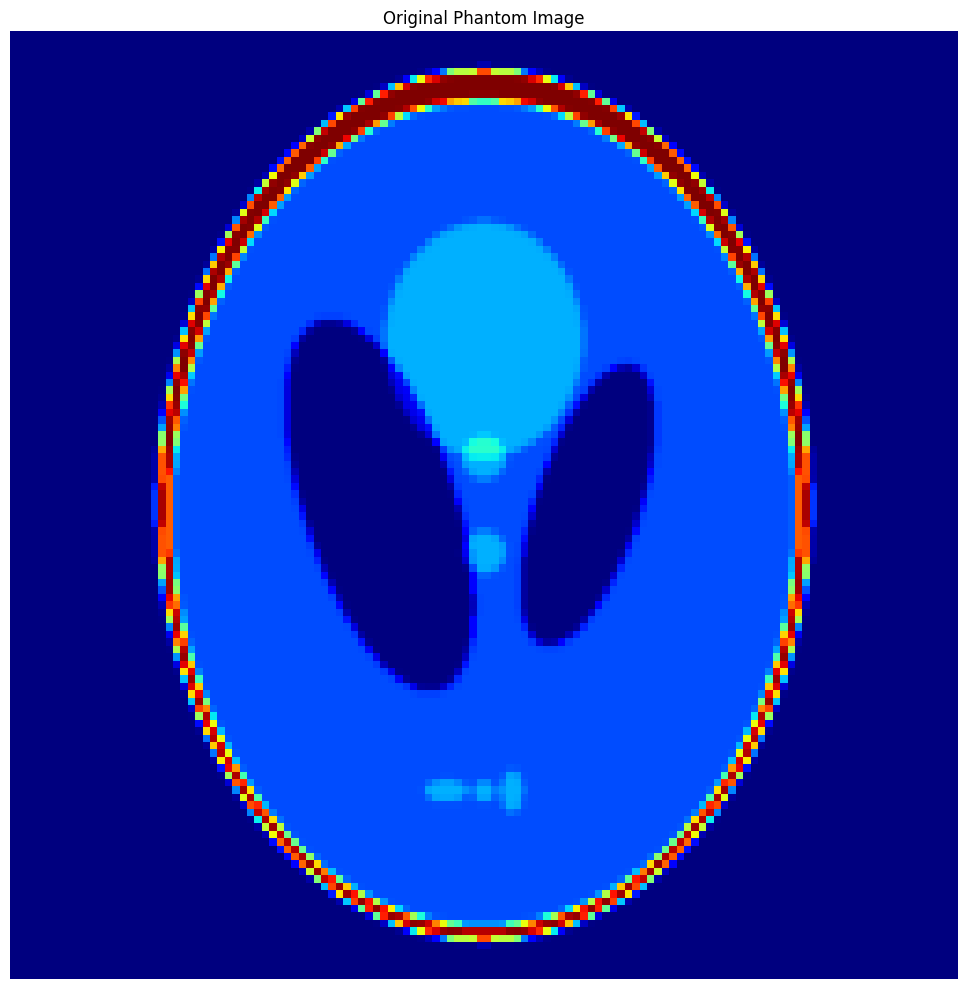

In [100]:
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(phantom, cmap='jet')
ax.set_title('Original Phantom Image')
ax.axis('off')
plt.tight_layout()


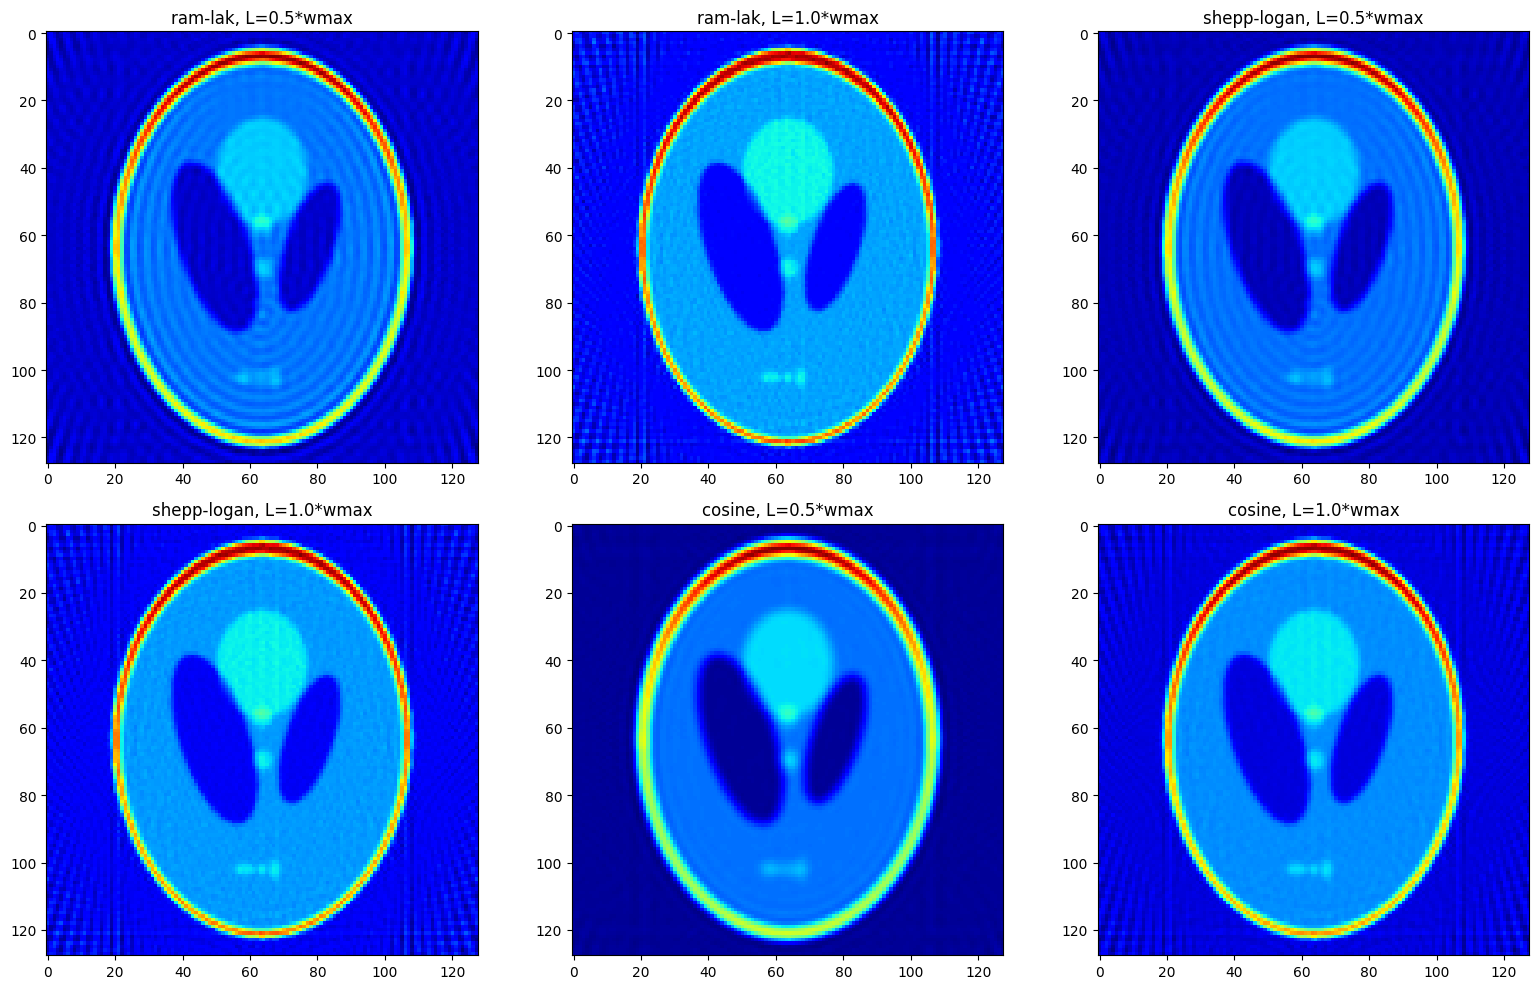

In [101]:
fig, axs = plt.subplots(2,3, figsize=(16,10))
i=0
for filt in filters:
    for j,L in enumerate([wmax/2, wmax]):
        ax = axs.flatten()[i]
        ax.imshow(results[(filt,L)], cmap='jet')
        ax.set_title(f'{filt}, L={(j+1)/2}*wmax')
        i+=1
plt.tight_layout()


In [102]:
def rrmse(A,B):
    return np.linalg.norm(A-B)/np.linalg.norm(A)
S0 = phantom
S1 = gaussian(S0, sigma=1, preserve_range=True)
S5 = gaussian(S0, sigma=5, preserve_range=True)
Slist = [S0, S1, S5]
Rlist = []
for S in Slist:
    s = radon(S, theta=theta, circle=False)
    sf = myFilter(s, filter_type='ram-lak', L=wmax)
    R = iradon(sf, theta=theta, filter_name=None, circle=False)
    Rlist.append(R)
errs = [rrmse(Slist[i], Rlist[i]) for i in range(3)]
errs

[np.float64(0.1739129694538362),
 np.float64(0.05719350400764652),
 np.float64(0.026199530554613458)]

Text(0, 0.5, 'RRMSE')

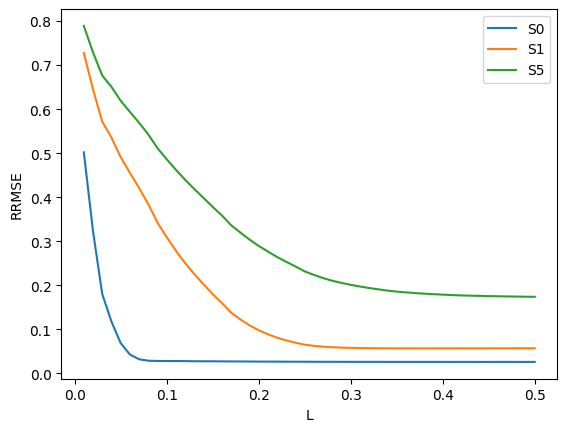

In [105]:
Ls = np.linspace(wmax/50, wmax, 50)
vals = np.zeros((3, len(Ls)))
for k,S in enumerate(Slist):
    s = radon(S, theta=theta, circle=False)
    for i,L in enumerate(Ls):
        sf = myFilter(s, filter_type='ram-lak', L=L)
        R = iradon(sf, theta=theta, filter_name=None, circle=False)
        vals[k,i] = rrmse(S, R)
plt.figure()
for k,label in enumerate(['S0','S1','S5']):
    plt.plot(Ls, vals[2-k], label=label)
plt.legend(); plt.xlabel('L'); plt.ylabel('RRMSE')

RRMSE values:
Blur σ=1 vs Original (S1 vs S0): 0.262926
Blur σ=5 vs Original (S5 vs S0): 0.627685
Reconstruction of S0 (R0 vs S0): 0.173913
Reconstruction of S1 (R1 vs S1): 0.057194
Reconstruction of S5 (R5 vs S5): 0.026200


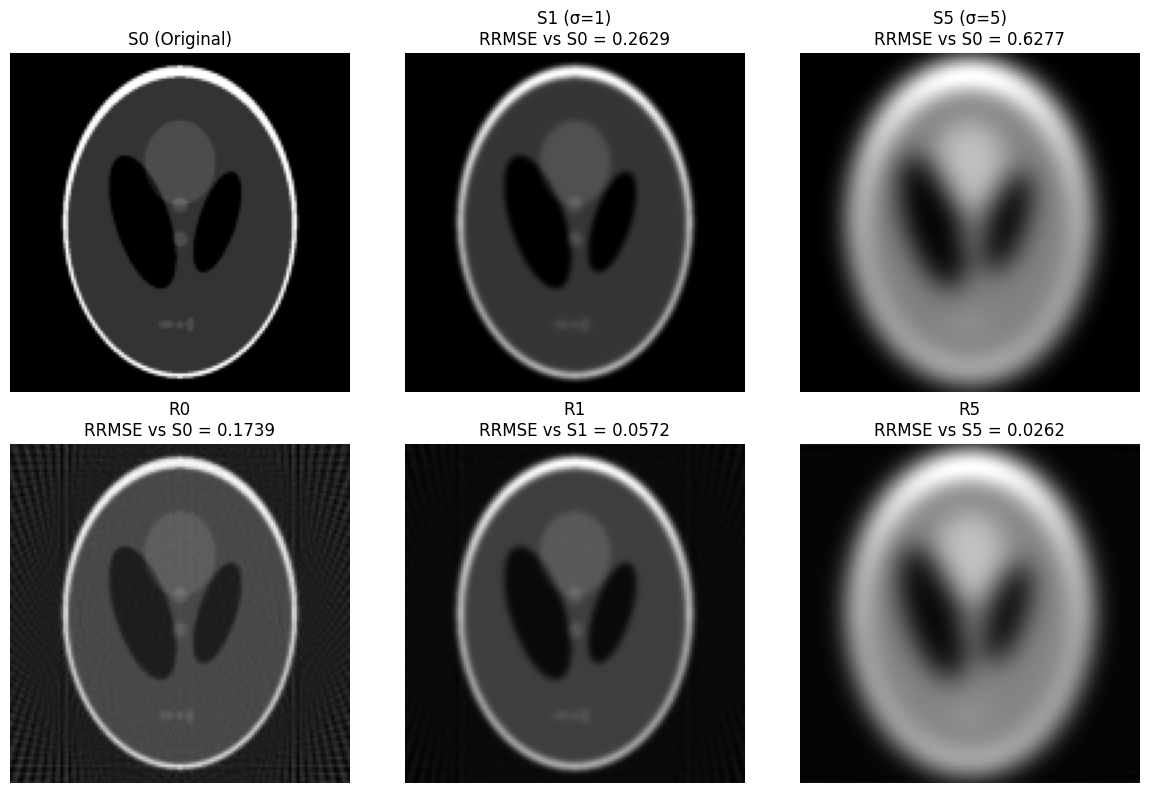

In [104]:
R0, R1, R5 = Rlist

rrmse_S1 = rrmse(S0, S1)
rrmse_S5 = rrmse(S0, S5)

rrmse_R0 = rrmse(S0, R0)
rrmse_R1 = rrmse(S1, R1)
rrmse_R5 = rrmse(S5, R5)


print("RRMSE values:")
print(f"Blur σ=1 vs Original (S1 vs S0): {rrmse_S1:.6f}")
print(f"Blur σ=5 vs Original (S5 vs S0): {rrmse_S5:.6f}")
print(f"Reconstruction of S0 (R0 vs S0): {rrmse_R0:.6f}")
print(f"Reconstruction of S1 (R1 vs S1): {rrmse_R1:.6f}")
print(f"Reconstruction of S5 (R5 vs S5): {rrmse_R5:.6f}")


fig, axes = plt.subplots(2, 3, figsize=(12,8))

axes[0,0].imshow(S0, cmap='gray')
axes[0,0].set_title("S0 (Original)")
axes[0,0].axis('off')

axes[0,1].imshow(S1, cmap='gray')
axes[0,1].set_title(f"S1 (σ=1)\nRRMSE vs S0 = {rrmse_S1:.4f}")
axes[0,1].axis('off')

axes[0,2].imshow(S5, cmap='gray')
axes[0,2].set_title(f"S5 (σ=5)\nRRMSE vs S0 = {rrmse_S5:.4f}")
axes[0,2].axis('off')

axes[1,0].imshow(R0, cmap='gray')
axes[1,0].set_title(f"R0\nRRMSE vs S0 = {rrmse_R0:.4f}")
axes[1,0].axis('off')

axes[1,1].imshow(R1, cmap='gray')
axes[1,1].set_title(f"R1\nRRMSE vs S1 = {rrmse_R1:.4f}")
axes[1,1].axis('off')

axes[1,2].imshow(R5, cmap='gray')
axes[1,2].set_title(f"R5\nRRMSE vs S5 = {rrmse_R5:.4f}")
axes[1,2].axis('off')


plt.tight_layout()


plt.show()